# Virtual screening with a 1D CNN on fingerprints

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/yboulaamane/cadd-labs/blob/main/cnn_fingerprints_vs.ipynb)

Can a neural network learn to tell MAO-B inhibitors from inactive compounds? Here each molecule
is a 2048-bit Morgan fingerprint, fed to a one-dimensional convolutional network, and trained on
real ChEMBL data. Crucially, you'll also pit it against a plain random forest, because a fancy
model is only worth it if it beats a simple one.

**What you'll do**

- Build the labelled MAO-B set and fingerprint it.
- Split cleanly, handle the class imbalance the right way, and train the CNN.
- Judge it on held-out compounds with ROC AUC and MCC, head to head with a random forest.

Runtime: a CPU runtime is enough; a GPU is faster.

## Setup

RDKit and imbalanced-learn are added; TensorFlow, pandas, scikit-learn, NumPy and Matplotlib are on Colab.

In [ ]:
%pip install -q rdkit imbalanced-learn seaborn

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="talk", palette="muted")
plt.rcParams.update({
    "figure.dpi": 120,
    "axes.titleweight": "bold",
    "axes.titlesize": 16,
    "axes.titlepad": 14,
    "savefig.bbox": "tight",
})

## Data: MAO-B inhibitors from ChEMBL

The compounds and their activities come from [ChEMBL](https://www.ebi.ac.uk/chembl/)
target [CHEMBL2039](https://www.ebi.ac.uk/chembl/explore/target/CHEMBL2039),
human monoamine oxidase B. The cell below downloads every activity record for
that target through the ChEMBL web services and turns them into one labelled row
per compound:

* Only IC50 and Ki values in nM that ChEMBL has not flagged as doubtful are used.
* Salts and counter-ions are stripped, so the different salt forms of one compound count once.
* A compound is **active (1)** if its median value is at most 316 nM (pIC50 &ge; 6.5) and
  **inactive (0)** if it is at least 10 &micro;M (pIC50 &le; 5). A compound reported only as
  "> 10 &micro;M" is also inactive. Compounds in between are left out.

The labelled table is saved to `maob_chembl_labelled.csv` and later runs read that file
instead of downloading again. Delete it to refresh the data. ChEMBL data is licensed under
[CC BY-SA 3.0](https://creativecommons.org/licenses/by-sa/3.0/).

In [3]:
TARGET = "CHEMBL2039"   # monoamine oxidase B, Homo sapiens
ACTIVE_NM = 316         # median IC50 or Ki at or below this: active   (pIC50 >= 6.5)
INACTIVE_NM = 10_000    # median IC50 or Ki at or above this: inactive (pIC50 <= 5)
DATA_FILE = "maob_chembl_labelled.csv"

In [4]:
import os
import time
from urllib.parse import urljoin

import numpy as np
import pandas as pd
import requests
from rdkit import Chem, RDLogger
from rdkit.Chem.MolStandardize import rdMolStandardize

RDLogger.DisableLog("rdApp.*")
CHEMBL_URL = "https://www.ebi.ac.uk"


def fetch_activities(target):
    """Every activity record ChEMBL holds for one target, 1000 per request."""
    url = f"{CHEMBL_URL}/chembl/api/data/activity.json"
    params = {"target_chembl_id": target, "limit": 1000}
    records = []
    while url:
        for attempt in range(5):
            try:
                response = requests.get(url, params=params, timeout=120)
                response.raise_for_status()
                break
            except requests.RequestException:
                if attempt == 4:
                    raise
                time.sleep(2 ** attempt)
        page = response.json()
        records += page["activities"]
        print(f"\rDownloaded {len(records)} of {page['page_meta']['total_count']} records", end="")
        next_page = page["page_meta"]["next"]
        url, params = (urljoin(CHEMBL_URL, next_page), None) if next_page else (None, None)
    print()
    if not records:
        raise ValueError(f"ChEMBL returned no activity records for {target}")
    return pd.DataFrame(records)


def parent_smiles(smiles):
    """Canonical SMILES of the largest fragment, neutralised, or None if RDKit cannot read it."""
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    try:
        return Chem.MolToSmiles(rdMolStandardize.ChargeParent(mol))
    except Exception:
        return None


def label_molecules(activities):
    """One row per parent structure: its first ChEMBL ID, SMILES and label (1 active, 0 inactive)."""
    a = activities.copy()
    a["relation"] = a["standard_relation"].fillna("").str.strip("'")
    a["value"] = pd.to_numeric(a["standard_value"], errors="coerce")
    usable = (a["standard_type"].isin(["IC50", "Ki"]) & (a["standard_units"] == "nM")
              & a["data_validity_comment"].isna() & a["canonical_smiles"].notna()
              & (a["value"] > 0))
    a = a[usable].copy()
    a["smiles"] = a["canonical_smiles"].map(parent_smiles)
    a = a[a["smiles"].notna()]

    median = a[a["relation"] == "="].groupby("smiles")["value"].median()
    labels = pd.Series(np.nan, index=median.index)
    labels[median <= ACTIVE_NM] = 1
    labels[median >= INACTIVE_NM] = 0

    # Compounds with no exact value, only "> x" with x of at least INACTIVE_NM
    above = a[a["relation"].isin([">", ">="]) & (a["value"] >= INACTIVE_NM)]["smiles"]
    only_above = pd.Index(above.unique()).difference(median.index)
    labels = pd.concat([labels, pd.Series(0.0, index=only_above)]).dropna().astype(int)

    first_id = a.sort_values("molecule_chembl_id").groupby("smiles")["molecule_chembl_id"].first()
    data = pd.DataFrame({"molecule_chembl_id": first_id[labels.index].to_numpy(),
                         "smiles": labels.index.to_numpy(),
                         "label": labels.to_numpy()})
    return data.sort_values("molecule_chembl_id", ignore_index=True)

In [5]:
if os.path.exists(DATA_FILE):
    data = pd.read_csv(DATA_FILE)
else:
    data = label_molecules(fetch_activities(TARGET))
    data.to_csv(DATA_FILE, index=False)

n_active = int(data["label"].sum())
print(f"{len(data)} compounds: {n_active} active, {len(data) - n_active} inactive")
data.head()

Downloaded 17947 of 17947 records
3894 compounds: 1538 active, 2356 inactive


,molecule_chembl_id,smiles,label
0,CHEMBL103879,COc1ccc2c(c1)SCC(=O)N2,0
1,CHEMBL104,Clc1ccccc1C(c1ccccc1)(c1ccccc1)n1ccnc1,0
2,CHEMBL106771,O=C(/C=C/c1ccc([N+](=O)[O-])cc1)c1ccccc1,1
3,CHEMBL106824,O=C(/C=C/c1cccc([N+](=O)[O-])c1)c1ccccc1,1
4,CHEMBL1076153,NC(=S)N1N=C(c2ccc(Cl)cc2)CC1c1ccc[nH]1,0


## Fingerprints

Morgan fingerprints of radius 2 (ECFP4), folded to 2048 bits, one row per compound.

In [6]:
from rdkit.Chem import rdFingerprintGenerator

morgan = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=2048)
X = np.array([morgan.GetFingerprintAsNumPy(Chem.MolFromSmiles(s)) for s in data["smiles"]],
             dtype=np.uint8)
print("Feature matrix:", X.shape)

Feature matrix: (3894, 2048)


## Split the data before doing anything else

70% of the compounds train the model, 10% decide when to stop, and 20% are locked away until
the very end. Keeping that test set untouched is the single most important habit in ML for drug
discovery: every score you report should come from compounds the model has never seen. The split
is **stratified**, so each part keeps the same share of actives.

One honest caveat: a random split still lets close analogues of training compounds land in the
test set, which flatters the scores. Splitting by scaffold is the harder, more realistic test.

In [7]:
from sklearn.model_selection import train_test_split

y = data["label"].to_numpy()
idx_train, idx_test = train_test_split(np.arange(len(data)), test_size=0.2, stratify=y, random_state=42)
idx_train, idx_valid = train_test_split(idx_train, test_size=0.125, stratify=y[idx_train], random_state=42)

for name, idx in [("train", idx_train), ("validation", idx_valid), ("test", idx_test)]:
    print(f"{name:>10}: {len(idx):5d} compounds, {y[idx].mean():.0%} active")

     train:  2725 compounds, 39% active
validation:   390 compounds, 39% active
      test:   779 compounds, 40% active


In [8]:
X_train, X_valid, X_test = X[idx_train], X[idx_valid], X[idx_test]
y_train, y_valid, y_test = y[idx_train], y[idx_valid], y[idx_test]

There are more inactives than actives, so the minority class is oversampled, **in the training
set only**. Doing this before the split would copy training compounds into the test set and
quietly inflate every score, a classic leakage trap.

In [9]:
from imblearn.over_sampling import RandomOverSampler

X_train_bal, y_train_bal = RandomOverSampler(random_state=0).fit_resample(X_train, y_train)
print("Training set (inactive, active):", np.bincount(y_train), "->", np.bincount(y_train_bal))

Training set (inactive, active): [1649 1076] -> [1649 1649]


## The model

An embedding turns each bit into a short learned vector, so the fingerprint becomes a sequence a
1D convolution can scan. Worth knowing: the bit order in a folded fingerprint comes from a hash
and carries no chemical meaning, so "neighbouring" bits are not related fragments. That is a real
reason to keep the random-forest baseline honest later.

In [10]:
from tensorflow import keras
from tensorflow.keras import layers

keras.utils.set_random_seed(42)

model = keras.Sequential([
    keras.Input(shape=(X.shape[1],)),
    layers.Embedding(input_dim=2, output_dim=150),
    layers.Conv1D(300, 16, activation="relu"),
    layers.MaxPooling1D(3),
    layers.Flatten(),
    layers.Dense(1, activation="sigmoid"),
], name="maob_1d_cnn")
model.compile(loss="binary_crossentropy", optimizer=keras.optimizers.Adam(learning_rate=1e-4),
              metrics=["accuracy", keras.metrics.AUC(name="auc")])
model.summary()

Model: "maob_1d_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 2048, 150)      │           300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 2033, 300)      │       720,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 677, 300)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 203100)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │       203,101 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 923,701 (3.52 MB)

 Trainable params: 923,701 (3.52 MB)

 Non-trainable params: 0 (0.00 B)

The learning rate is set ten times below Adam's default: at the default this model sometimes
collapses to predicting one constant probability for everything. Training stops early when the
validation loss stalls and keeps the best weights.

In [11]:
callbacks = [
    keras.callbacks.EarlyStopping(monitor="val_loss", patience=3, min_delta=1e-4, restore_best_weights=True),
    keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.1, patience=2, min_delta=1e-4),
    keras.callbacks.CSVLogger("maob_cnn_fp_training.csv"),
]
history = model.fit(X_train_bal, y_train_bal, validation_data=(X_valid, y_valid),
                    epochs=30, batch_size=16, callbacks=callbacks)

Epoch 1/30
207/207 ━━━━━━━━━━━━━━━━━━━━ 134s 643ms/step - accuracy: 0.7210 - auc: 0.7937 - loss: 0.5608 - val_accuracy: 0.8205 - val_auc: 0.9091 - val_loss: 0.4046 - learning_rate: 1.0000e-04
Epoch 2/30
207/207 ━━━━━━━━━━━━━━━━━━━━ 135s 653ms/step - accuracy: 0.8590 - auc: 0.9330 - loss: 0.3290 - val_accuracy: 0.8538 - val_auc: 0.9317 - val_loss: 0.3307 - learning_rate: 1.0000e-04
Epoch 3/30
207/207 ━━━━━━━━━━━━━━━━━━━━ 135s 654ms/step - accuracy: 0.8972 - auc: 0.9588 - loss: 0.2579 - val_accuracy: 0.8718 - val_auc: 0.9374 - val_loss: 0.3126 - learning_rate: 1.0000e-04
Epoch 4/30
207/207 ━━━━━━━━━━━━━━━━━━━━ 136s 657ms/step - accuracy: 0.9160 - auc: 0.9721 - loss: 0.2132 - val_accuracy: 0.8667 - val_auc: 0.9373 - val_loss: 0.3147 - learning_rate: 1.0000e-04
Epoch 5/30
207/207 ━━━━━━━━━━━━━━━━━━━━ 134s 650ms/step - accuracy: 0.9278 - auc: 0.9795 - loss: 0.1823 - val_accuracy: 0.8590 - val_auc: 0.9364 - val_loss: 0.3293 - learning_rate: 1.0000e-04
Epoch 6/30
207/207 ━━━━━━━━━━━━━━━━━━━━ 

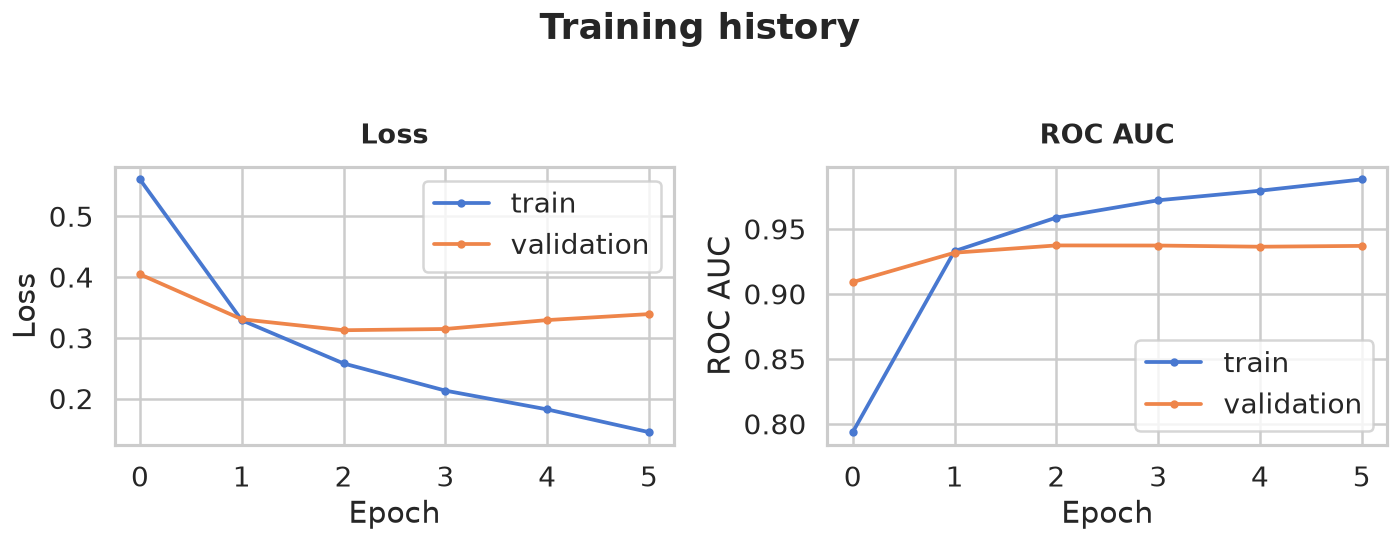

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for ax, metric, title in zip(axes, ["loss", "auc"], ["Loss", "ROC AUC"]):
    ax.plot(history.history[metric], marker="o", ms=4, label="train")
    ax.plot(history.history[f"val_{metric}"], marker="o", ms=4, label="validation")
    ax.set(xlabel="Epoch", ylabel=title, title=title)
    ax.legend(frameon=True)
fig.suptitle("Training history", y=1.02, fontweight="bold")
plt.tight_layout()
plt.show()

## How good is it, really?

These scores come from the locked-away test set. ROC AUC is threshold-free; MCC and the report
use the 0.5 cut-off and are blunter but more intuitive.

ROC AUC: 0.955
MCC:     0.762

              precision    recall  f1-score   support

    inactive       0.92      0.89      0.90       471
      active       0.83      0.88      0.86       308

    accuracy                           0.88       779
   macro avg       0.88      0.88      0.88       779
weighted avg       0.89      0.88      0.88       779



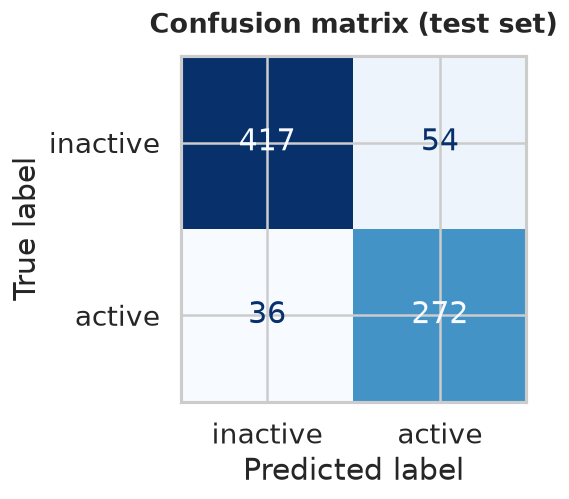

In [13]:
from sklearn.metrics import (ConfusionMatrixDisplay, classification_report,
                             matthews_corrcoef, roc_auc_score)

p_test = model.predict(X_test, verbose=0).ravel()
pred_test = (p_test >= 0.5).astype(int)

print(f"ROC AUC: {roc_auc_score(y_test, p_test):.3f}")
print(f"MCC:     {matthews_corrcoef(y_test, pred_test):.3f}\n")
print(classification_report(y_test, pred_test, target_names=["inactive", "active"]))

fig, ax = plt.subplots(figsize=(5, 4.5))
ConfusionMatrixDisplay.from_predictions(y_test, pred_test, display_labels=["inactive", "active"],
                                        cmap="Blues", colorbar=False, ax=ax)
ax.set_title("Confusion matrix (test set)")
plt.tight_layout()
plt.show()

## Reality check: a random forest on the same split

Before celebrating a neural network, see whether something simpler does just as well. A random
forest on the same fingerprints trains in seconds and needs no tuning. If the network cannot beat
it on the same held-out compounds, the extra complexity is not earning its keep.

In [14]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=500, class_weight="balanced", n_jobs=-1, random_state=42)
rf.fit(X_train, y_train)
p_rf = rf.predict_proba(X_test)[:, 1]
print(f"Random forest ROC AUC: {roc_auc_score(y_test, p_rf):.3f}")

Random forest ROC AUC: 0.977


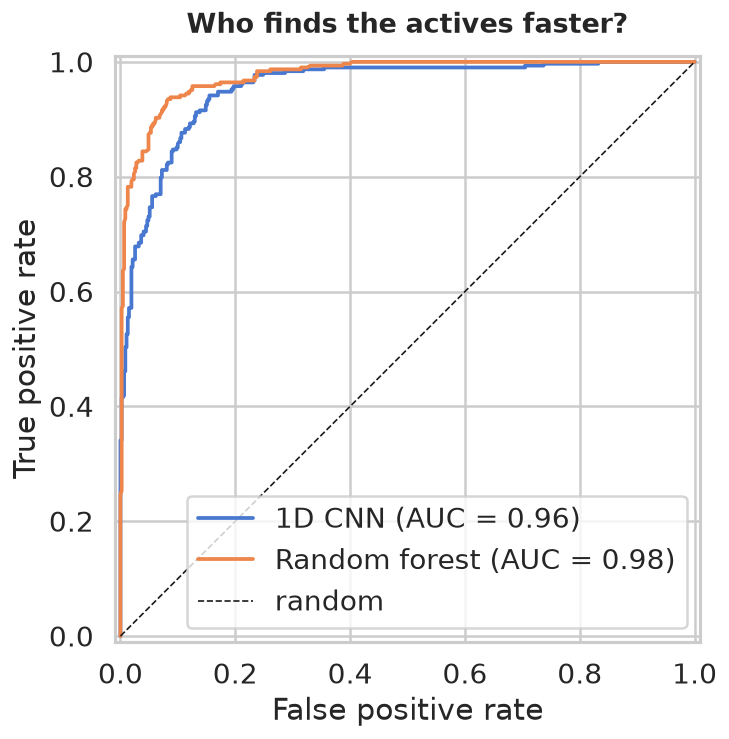

In [15]:
from sklearn.metrics import RocCurveDisplay

fig, ax = plt.subplots(figsize=(6.5, 6.5))
RocCurveDisplay.from_predictions(y_test, p_test, name="1D CNN", ax=ax)
RocCurveDisplay.from_predictions(y_test, p_rf, name="Random forest", ax=ax)
ax.plot([0, 1], [0, 1], "k--", linewidth=1, label="random")
ax.set(title="Who finds the actives faster?", xlabel="False positive rate", ylabel="True positive rate")
ax.legend(loc="lower right", frameon=True)
plt.tight_layout()
plt.show()

## Takeaways

- A clean split, training-only oversampling, and a simple baseline are what make a screening
  score trustworthy. The architecture matters less than these habits.
- On fingerprints, a random forest is a famously strong baseline. Beating it convincingly is the
  bar a neural network has to clear, and here it does not: the forest scores the higher test AUC
  after seconds of training, against minutes for the CNN.
- The training history shows the classic overfitting signature: training loss keeps falling while
  validation loss turns back up after a couple of epochs. Early stopping is what keeps the best
  weights from before that turn.
- Next: try a scaffold split for a tougher, fairer test, or swap the fingerprint for ECFP6.

The trained model is saved below.

In [16]:
model.save("maob_cnn_fp.keras")

try:  # on Colab, offer the saved model as a download
    from google.colab import files
    files.download("maob_cnn_fp.keras")
except ImportError:
    pass